In [20]:

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib




In [21]:


df = pd.read_csv('KXBQQF (1).csv')


df.head()


,Unnamed: 0,Student_ID,Student_Name,Study_Hours_Per_Day,Attendance_%,Previous_GPA,Assignments_Submitted,Sleep_Hours,Final_Marks
0,0,STU001,Fatima Noor,4.4,90.4,3.85,1.0,6.1,1
1,1,STU002,Ali Hassan,9.6,94.8,3.88,2.0,8.5,1
2,2,STU003,Hamza Sheikh,NaN,65.9,NaN,0.0,4.6,1
3,3,STU004,Zainab Hussain,6.4,55.5,2.43,0.0,NaN,1
4,4,STU005,Zainab Hussain,99.0,NaN,1.54,2.0,NaN,0


In [3]:


print("Dataset Shape:", df.shape)

# Dataset Information
df.info()


Dataset Shape: (125, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             125 non-null    int64  
 1   Student_ID             125 non-null    object 
 2   Student_Name           125 non-null    object 
 3   Study_Hours_Per_Day    114 non-null    float64
 4   Attendance_%           114 non-null    float64
 5   Previous_GPA           115 non-null    float64
 6   Assignments_Submitted  125 non-null    object 
 7   Sleep_Hours            115 non-null    object 
 8   Final_Marks            125 non-null    int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 8.9+ KB


In [4]:

# Summary Statistics
df.describe(include='all')


,Unnamed: 0,Student_ID,Student_Name,Study_Hours_Per_Day,Attendance_%,Previous_GPA,Assignments_Submitted,Sleep_Hours,Final_Marks
count,125.000000,125,125,114.000000,114.000000,115.000000,125,115,125.000000
unique,NaN,120,30,NaN,NaN,NaN,12,43,NaN
top,NaN,STU027,Hamza Sheikh,NaN,NaN,NaN,9.0,8.8,NaN
freq,NaN,2,11,NaN,NaN,NaN,17,7,NaN
mean,62.000000,NaN,NaN,6.160526,75.514912,2.848870,NaN,NaN,0.864000
std,36.228442,NaN,NaN,9.401399,21.434045,1.069368,NaN,NaN,0.344168
min,0.000000,NaN,NaN,-3.000000,-10.000000,-1.000000,NaN,NaN,0.000000
25%,31.000000,NaN,NaN,2.800000,62.025000,2.235000,NaN,NaN,1.000000
50%,62.000000,NaN,NaN,5.300000,75.300000,2.870000,NaN,NaN,1.000000
75%,93.000000,NaN,NaN,7.900000,86.375000,3.370000,NaN,NaN,1.000000


In [5]:

# Check Missing Values
print(df.isnull().sum())


Unnamed: 0                0
Student_ID                0
Student_Name              0
Study_Hours_Per_Day      11
Attendance_%             11
Previous_GPA             10
Assignments_Submitted     0
Sleep_Hours              10
Final_Marks               0
dtype: int64


In [6]:

# Check Duplicate Rows
print("Duplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0



# Exploratory Data Analysis (EDA)


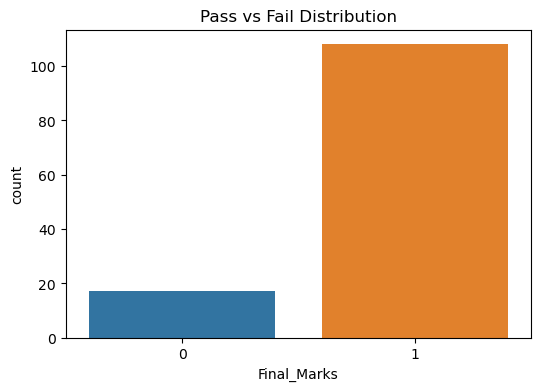

In [7]:

# Target Variable Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Final_Marks', data=df)
plt.title('Pass vs Fail Distribution')
plt.show()


In [8]:

# Drop unnecessary columns
df = df.drop(columns=['Unnamed: 0', 'Student_ID'])

# Features and Target
X = df.drop('Final_Marks', axis=1)
y = df['Final_Marks']

# Identify Numerical and Categorical Columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)


Numerical Features: ['Study_Hours_Per_Day', 'Attendance_%', 'Previous_GPA']
Categorical Features: ['Student_Name', 'Assignments_Submitted', 'Sleep_Hours']



# Train-Test Split


In [15]:

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (100, 6)
Testing Shape: (25, 6)


In [16]:

# Numerical Pipeline
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('power_transform', PowerTransformer()),
    ('scaler', StandardScaler())
])

# Categorical Pipeline
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Column Transformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])



# Machine Learning Pipeline


In [17]:

# Logistic Regression Pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

# Train Model
model_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('power_transform',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Study_Hours_Per_Day',
                                                   'Attendance_%',
                                                   'Previous_GPA']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Student_Name',
                                                   'Assignments_Submitted',
                                                   'Sleep_Hours'])])),
                ('classifier', LogisticRegression())])


# Model Evaluation


In [18]:

# Predictions
y_pred = model_pipeline.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)


Accuracy : 0.88
Precision: 0.88
Recall   : 1.0
F1 Score : 0.9361702127659575


In [19]:

# Classification Report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.88      1.00      0.94        22

    accuracy                           0.88        25
   macro avg       0.44      0.50      0.47        25
weighted avg       0.77      0.88      0.82        25




# Save Final Model


In [25]:

# Save Model
joblib.dump(model_pipeline, 'student_performance_model.pkl')

print("Model saved successfully!")


Model saved successfully!


In [26]:
model=joblib.load('student_performance_model.pkl')

In [57]:

new_data = pd.DataFrame([{
    'Student_Name': 'Ali',

    'Study_Hours_Per_Day': 0,
    'Attendance_%': 0,
    'Previous_GPA':3 ,
    'Assignments_Submitted': 0,
    'Sleep_Hours': 24,

    'Gender': 'Male',
    'Parental_Education_Level': 'Bachelor',
    'Internet_Access_at_Home': 'Yes',
    'Extracurricular_Activities': 'Yes'
}])

In [58]:
prediction = model.predict(new_data)

In [59]:
print("prediction:",prediction[0])

prediction: 1


In [55]:
if prediction[0]==1:
    print("student will pass")
else:
    print("Student will fill")

student will pass
